# Lesson 6.4 - Monitoring, Drift & Governance (toy drift demo)

This notebook simulates production drift monitoring using statistical comparisons between reference training data and a production-like stream.

## Objectives

- Simulate baseline vs production feature distributions.
- Compute drift metrics (PSI and KS statistic).
- Build simple drift alert rules.
- Connect metric behavior to governance and retraining decisions.

## Setup

In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

SEED = 42
rng = np.random.default_rng(SEED)

ARTIFACT_DIR = Path("artifacts/lesson6_4")
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

## Section A - Simulate Reference vs Production Data

In [2]:
n_ref = 5000
n_prod = 2500

ref = pd.DataFrame(
    {
        "transaction_amount": np.clip(rng.normal(70, 25, size=n_ref), 1, None),
        "num_prev_txn_24h": rng.poisson(2.2, size=n_ref),
        "device_risk_score": np.clip(rng.beta(2.2, 6.5, size=n_ref), 0, 1),
    }
)

prod = pd.DataFrame(
    {
        "transaction_amount": np.clip(rng.normal(88, 33, size=n_prod), 1, None),
        "num_prev_txn_24h": rng.poisson(3.1, size=n_prod),
        "device_risk_score": np.clip(rng.beta(3.4, 5.0, size=n_prod), 0, 1),
    }
)

ref.describe().T[["mean", "std"]], prod.describe().T[["mean", "std"]]

(                         mean        std
 transaction_amount  69.520757  24.934082
 num_prev_txn_24h     2.215800   1.492674
 device_risk_score    0.254707   0.141685,
                          mean        std
 transaction_amount  86.884087  32.718431
 num_prev_txn_24h     3.132000   1.753570
 device_risk_score    0.409642   0.160600)

## Section B - Drift Metrics (PSI + KS)

- **PSI** helps quantify bin-wise population shifts.
- **KS statistic** compares cumulative distributions.

In [3]:
def compute_psi(reference: np.ndarray, current: np.ndarray, bins: int = 10, eps: float = 1e-6) -> float:
    quantiles = np.linspace(0, 1, bins + 1)
    breaks = np.quantile(reference, quantiles)
    breaks = np.unique(breaks)
    if len(breaks) < 3:
        return 0.0

    ref_counts, _ = np.histogram(reference, bins=breaks)
    cur_counts, _ = np.histogram(current, bins=breaks)

    ref_pct = ref_counts / max(ref_counts.sum(), 1)
    cur_pct = cur_counts / max(cur_counts.sum(), 1)

    ref_pct = np.clip(ref_pct, eps, None)
    cur_pct = np.clip(cur_pct, eps, None)

    psi = np.sum((cur_pct - ref_pct) * np.log(cur_pct / ref_pct))
    return float(psi)


def compute_ks(reference: np.ndarray, current: np.ndarray) -> float:
    ref_sorted = np.sort(reference)
    cur_sorted = np.sort(current)

    all_vals = np.sort(np.unique(np.concatenate([ref_sorted, cur_sorted])))
    ref_cdf = np.searchsorted(ref_sorted, all_vals, side="right") / len(ref_sorted)
    cur_cdf = np.searchsorted(cur_sorted, all_vals, side="right") / len(cur_sorted)
    return float(np.max(np.abs(ref_cdf - cur_cdf)))


metrics = {}
for col in ref.columns:
    metrics[col] = {
        "psi": compute_psi(ref[col].values, prod[col].values, bins=10),
        "ks": compute_ks(ref[col].values, prod[col].values),
    }

pd.DataFrame(metrics).T

,psi,ks
transaction_amount,0.390801,0.2592
num_prev_txn_24h,0.292451,0.2272
device_risk_score,1.021629,0.3944


## Section C - Alerting Rules

In [4]:
alert_rows = []
for feature, vals in metrics.items():
    psi = vals["psi"]
    ks = vals["ks"]

    severity = "ok"
    if psi > 0.25 or ks > 0.2:
        severity = "high"
    elif psi > 0.1 or ks > 0.1:
        severity = "moderate"

    alert_rows.append({"feature": feature, "psi": psi, "ks": ks, "severity": severity})

alerts_df = pd.DataFrame(alert_rows)
alerts_df.sort_values(by=["severity", "psi"], ascending=[True, False])

,feature,psi,ks,severity
2,device_risk_score,1.021629,0.3944,high
0,transaction_amount,0.390801,0.2592,high
1,num_prev_txn_24h,0.292451,0.2272,high


## Section D - Visualize Drift

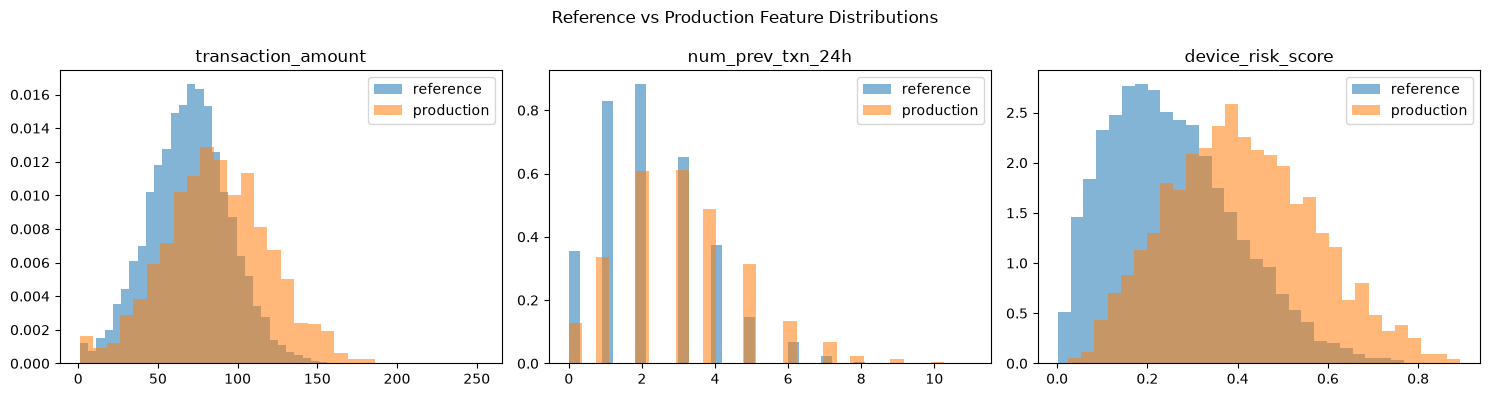

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ref.columns):
    ax.hist(ref[col], bins=30, alpha=0.55, label="reference", density=True)
    ax.hist(prod[col], bins=30, alpha=0.55, label="production", density=True)
    ax.set_title(col)
    ax.legend()

plt.suptitle("Reference vs Production Feature Distributions")
plt.tight_layout()
plt.show()

## Connect to Theory

- These metrics represent early-warning signals in a monitoring system.
- In production, metrics are computed on schedules and wired to alert channels.
- Drift alerts should route to runbooks: inspect source changes, evaluate performance, decide retraining/rollback.
- Governance requires preserving metric history, triggered actions, and approval outcomes.

## Business Case Studies & Exceptions

### Case 1: Fraud model degradation

- **Pattern**: rising PSI in transaction features predicts upcoming precision drop.
- **Action**: trigger focused model evaluation and controlled retraining.
- **Risk**: retraining too quickly on noisy windows can destabilize performance.

### Case 2: Governance-heavy financial deployment

- **Pattern**: threshold breaches generate documented incidents and required sign-offs.
- **Action**: monitoring records become audit evidence for model risk committees.

### Alert Threshold Trade-offs

- Low thresholds catch issues early but create alert fatigue.
- High thresholds reduce noise but may detect too late.
- Best practice: use persistent breach windows and severity tiers.

## Interview Questions & Answers

1. **Q: What is data drift?**
   **A:** A change in input feature distribution between reference and production data.

2. **Q: What is PSI used for?**
   **A:** Quantifying distribution shift between two populations using bucketed proportions.

3. **Q: What does a KS statistic represent?**
   **A:** The maximum distance between two empirical cumulative distribution functions.

4. **Q: Does drift always mean model performance dropped?**
   **A:** No. Drift is a risk signal; performance impact must be validated.

5. **Q: How do you set drift alert thresholds?**
   **A:** Based on historical variability, business risk tolerance, and backtested incident outcomes.

6. **Q: Why monitor by segment, not only globally?**
   **A:** Aggregates can hide severe drift in high-risk cohorts.

7. **Q: What should happen after a high-severity drift alert?**
   **A:** Trigger incident playbook: data pipeline checks, model re-evaluation, and retraining decision.

8. **Q: What is governance in this context?**
   **A:** Controlled, auditable processes for monitoring, response, approvals, and accountability.

9. **Q: How do you avoid alert fatigue?**
   **A:** Use severity tiers, persistence windows, and context-rich alerts.

10. **Q: What is prediction drift?**
   **A:** Shift in output score/class distribution over time.

11. **Q: When should retraining be blocked despite drift?**
   **A:** When drift is transient/noisy or data quality is uncertain.

12. **Q: What evidence should be stored for audits?**
   **A:** Monitoring metrics, breach timestamps, model versions, decisions taken, and approval records.
